Extracting EDF parameters from E:\aditi_eeg\visual_eeg\tbi\p1_a_2026-04-06_11-01-25_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 111499  =      0.000 ...   222.998 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 3301 samples (6.602 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']
Multiple event values for single event times found. Keeping the first occurrence and dropping all others.
Not setting metadata
87 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 87 events and 501 original time points ...
2 bad epochs dropped


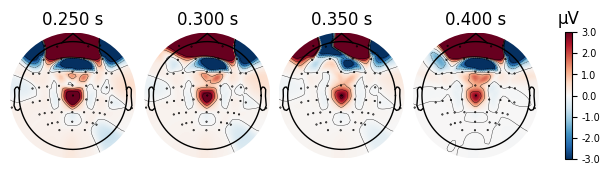

In [4]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# ================= LOAD EEG =================
file_path = r"E:\aditi_eeg\visual_eeg\tbi\p1_a_2026-04-06_11-01-25_Segment_0.edf"
raw = mne.io.read_raw_edf(file_path, preload=True)

# ================= FILTER =================
raw.filter(0.5, 30)

# ================= CLEAN CHANNEL NAMES =================
def clean_name(ch):
    ch = ch.replace("EEG ", "")
    ch = ch.replace("-CPz", "")
    ch = ch.replace("-REF", "")
    return ch

raw.rename_channels({ch: clean_name(ch) for ch in raw.ch_names})

# ================= SET MONTAGE =================
montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage, on_missing='ignore')

# ================= EVENTS =================
events, event_id = mne.events_from_annotations(raw)

# 🔥 FIX: handle duplicate event timestamps
if len(events) > 0:
    events = np.unique(events, axis=0)

# ================= EPOCHING =================
epochs = mne.Epochs(
    raw,
    events,
    event_id,
    tmin=-0.2,
    tmax=0.8,
    baseline=(None, 0),
    preload=True,
    event_repeated='drop'   # 🔥 IMPORTANT FIX
)

# ================= ERP =================
evoked = epochs.average()

# ================= P300 TOPOPLOT =================
times = [0.25, 0.30, 0.35, 0.40]

evoked.plot_topomap(
    times=times,
    ch_type="eeg",
    cmap="RdBu_r",
    time_unit="s",
    vlim=(-3, 3)
)

plt.show()

In [7]:
import numpy as np

# ================= CHANNELS =================
picks = ['Pz', 'Cz', 'CPz']
picks = [ch for ch in picks if ch in evoked.ch_names]

# ================= DATA =================
data = evoked.get_data(picks=picks)
times = evoked.times   # ✅ correct way

# average across channels
mean_signal = np.mean(data, axis=0)

# ================= P300 WINDOW (250–500 ms) =================
start = np.where(times >= 0.25)[0][0]
end = np.where(times <= 0.5)[0][-1]

p300_segment = mean_signal[start:end]
p300_times = times[start:end]

# ================= PEAK DETECTION =================
peak_idx = np.argmax(p300_segment)

p300_latency = p300_times[peak_idx]
p300_amplitude = p300_segment[peak_idx]

print("\n===== P300 RESULT =====")
print("Amplitude:", p300_amplitude)
print("Latency:", p300_latency, "seconds")


===== P300 RESULT =====
Amplitude: 1.2542316767864285e-06
Latency: 0.476 seconds


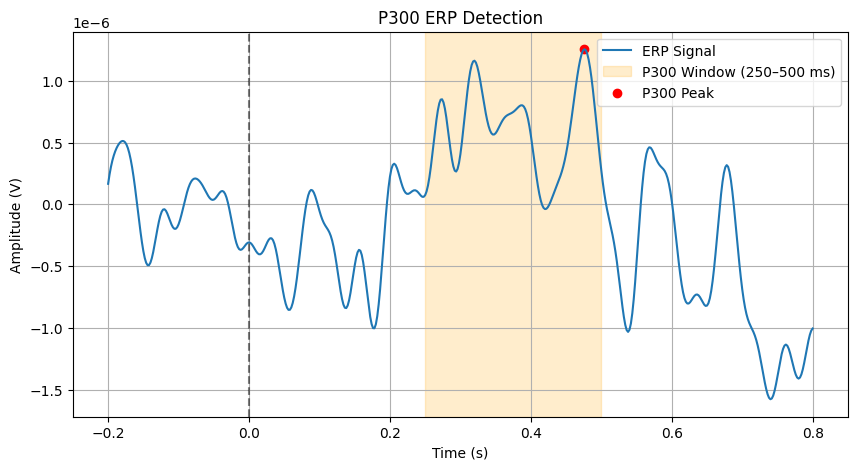

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ================= P300 WINDOW =================
start = np.where(times >= 0.25)[0][0]
end = np.where(times <= 0.5)[0][-1]

p300_segment = mean_signal[start:end]
p300_times = times[start:end]

# peak
peak_idx = np.argmax(p300_segment)
peak_time = p300_times[peak_idx]
peak_amp = p300_segment[peak_idx]

# ================= PLOT =================
plt.figure(figsize=(10, 5))

# full ERP
plt.plot(times, mean_signal, label="ERP Signal")

# highlight P300 window
plt.axvspan(0.25, 0.5, color='orange', alpha=0.2, label="P300 Window (250–500 ms)")

# peak point
plt.scatter(peak_time, peak_amp, color='red', label="P300 Peak")

# reference lines
plt.axvline(0, linestyle="--", color="black", alpha=0.5)

plt.title("P300 ERP Detection")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")
plt.legend()
plt.grid(True)

plt.show()